In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
books = [
    {"book_id": 1, "title": "Data Science for Everyone", "format": "hardcover", "price": 35},
    {"book_id": 2, "title": "Applied Machine Learning", "format": "paperback", "price": 28},
    {"book_id": 3, "title": "Python for Data Analysis", "format": "ebook", "price": 19},
    {"book_id": 4, "title": "Deep Learning Fundamentals", "format": "ebook", "price": 25},
]

books_df = pd.DataFrame(books)
books_df


,book_id,title,format,price
0,1,Data Science for Everyone,hardcover,35
1,2,Applied Machine Learning,paperback,28
2,3,Python for Data Analysis,ebook,19
3,4,Deep Learning Fundamentals,ebook,25


In [3]:
np.random.seed(42)
dates = pd.date_range(start="2025-01-01", end="2025-12-31", freq="D")

platforms = ["Amazon", "Barnes & Noble", "Apple Books", "Direct Website"]
data = []

for date in dates:
    for book in books:
        units_sold = np.random.poisson(lam=3)
        if units_sold > 0:
            data.append({
                "date": date,
                "book_id": book["book_id"],
                "platform": np.random.choice(platforms),
                "units_sold": units_sold,
                "ad_clicks": np.random.randint(0, 100),
                "page_views": np.random.randint(50, 500),
                "kenp_pages_read": np.random.randint(0, 300) if book["format"] == "ebook" else None
            })

sales_df = pd.DataFrame(data)
sales_df = sales_df.merge(books_df, on="book_id")


In [4]:
production_costs = {"hardcover": 10, "paperback": 6, "ebook": 2}
ad_cost_per_click = 0.50
design_cost = 3
editing_cost = 4

sales_df["unit_revenue"] = sales_df["price"]
sales_df["production_cost"] = sales_df["format"].map(production_costs)
sales_df["ad_cost_total"] = sales_df["ad_clicks"] * ad_cost_per_click

sales_df["net_profit"] = (
    sales_df["unit_revenue"] * sales_df["units_sold"]
    - (sales_df["production_cost"] * sales_df["units_sold"])
    - sales_df["ad_cost_total"]
    - (design_cost + editing_cost) * sales_df["units_sold"]
)


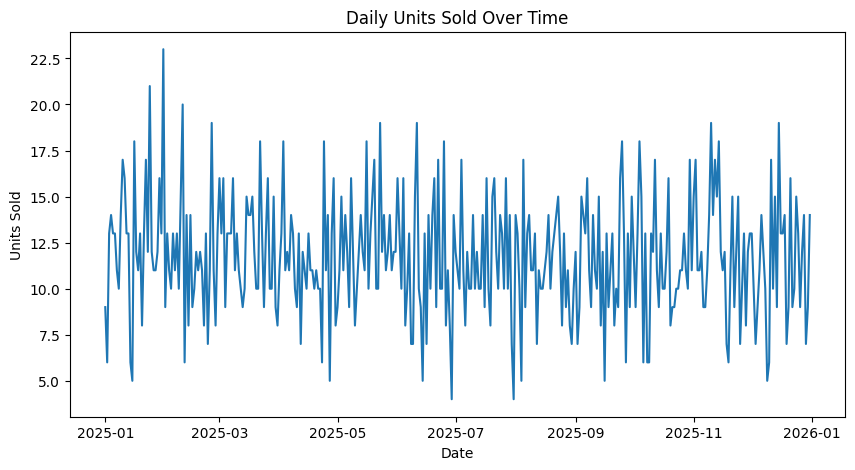

In [5]:
sales_trend = sales_df.groupby("date")["units_sold"].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(sales_trend["date"], sales_trend["units_sold"])
plt.title("Daily Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()


In [6]:
platform_summary = sales_df.groupby("platform")["units_sold"].sum().sort_values(ascending=False)
print(platform_summary)


platform
Direct Website    1200
Barnes & Noble    1071
Apple Books       1015
Amazon             998
Name: units_sold, dtype: int64


In [7]:
engagement = sales_df.dropna(subset=["kenp_pages_read"])
avg_engagement = engagement.groupby("title")["kenp_pages_read"].mean()
print(avg_engagement)


title
Deep Learning Fundamentals    149.617391
Python for Data Analysis      143.900875
Name: kenp_pages_read, dtype: float64


In [8]:
sales_df["conversion_rate"] = sales_df["units_sold"] / sales_df["page_views"]
conversion_summary = sales_df.groupby("title")["conversion_rate"].mean()
print(conversion_summary)


title
Applied Machine Learning      0.015982
Data Science for Everyone     0.015683
Deep Learning Fundamentals    0.016328
Python for Data Analysis      0.015306
Name: conversion_rate, dtype: float64


In [9]:
profit_summary = sales_df.groupby("title")["net_profit"].sum().sort_values(ascending=False)
print(profit_summary)


title
Data Science for Everyone     10031.5
Deep Learning Fundamentals     8775.0
Applied Machine Learning       8047.0
Python for Data Analysis       2471.5
Name: net_profit, dtype: float64


In [10]:
sales_df["year"] = sales_df["date"].dt.year
yoy = sales_df.groupby(["year", "title"])["units_sold"].sum().unstack()
print(yoy)


title  Applied Machine Learning  Data Science for Everyone  \
year                                                         
2025                       1096                       1036   

title  Deep Learning Fundamentals  Python for Data Analysis  
year                                                         
2025                         1077                      1075  
